## 1. Preprocess Lower Layer Data

In [36]:
from pathlib import Path
import pandas as pd

root = Path.cwd()
lower_layer_dir = root / "csv_output"
input_path = lower_layer_dir / "lower_layer_all.csv"
output_path = lower_layer_dir / "lower_layer_all_cleaned.csv"

if not input_path.exists():
    for parent in root.parents:
        candidate = parent / "csv_output" / "lower_layer_all.csv"
        if candidate.exists():
            input_path = candidate
            lower_layer_dir = candidate.parent
            output_path = lower_layer_dir / "lower_layer_all_cleaned.csv"
            break
    else:
        raise FileNotFoundError(f"Combined lower-layer dataset not found: {input_path}")

In [37]:
# Load combined lower-layer dataset
print(f"Loading dataset from: {input_path}")
df = pd.read_csv(input_path)
print(f"Loaded {len(df):,} rows and {len(df.columns):,} columns")

Loading dataset from: c:\Users\BLACKBOX\Desktop\Research Data\Iyenshi\Coding Assignment\csv_output\lower_layer_all.csv
Loaded 37,926 rows and 25 columns


C:\Users\BLACKBOX\AppData\Local\Temp\ipykernel_15024\4012927634.py:3: DtypeWarning: Columns (0: pmi) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_path)


In [38]:
# Display the first few rows of the dataset
df.head()

,ue_id,timestamp,cellid,in_sync,rnti,dlBytes,dlMcs,dlBler,ulBytes,ulMcs,...,pcmax,rsrq,sinr,rsrp,rssi,cqi,pucchSnr,puschSnr,attack_class,pmi
0,2.0,1.751374e+12,11111111.0,1.0,097a,541944552,23,0.064554,821528571,11,...,23,-10.5,23.0,-94,-75.8,15,20.0,22.0,Benign,NaN
1,15.0,1.751374e+12,11111111.0,1.0,de81,14016622,9,0.000000,69276604,9,...,25,-11.0,11.0,-101,-73.4,15,18.0,19.0,Benign,NaN
2,2.0,1.751374e+12,11111111.0,1.0,097a,541974006,24,0.178451,821535047,11,...,23,-10.5,23.5,-93,-75.9,15,19.0,23.5,Benign,NaN
3,15.0,1.751374e+12,11111111.0,1.0,de81,14019269,10,0.000000,69280245,9,...,25,-11.0,10.0,-100,-74.3,15,18.0,25.0,Benign,NaN
4,2.0,1.751374e+12,11111111.0,1.0,097a,542003058,23,0.069136,821557735,14,...,23,-10.5,23.5,-93,-72.0,15,19.0,17.5,Benign,NaN


In [39]:
# Drop rows without any data and duplicate rows
before = len(df)
df = df.dropna(how="all")
after_drop_all = len(df)
print(f"Dropped {before - after_drop_all:,} rows that were fully empty")

after_duplicates = len(df)
df = df.drop_duplicates()
print(f"Dropped {after_duplicates - len(df):,} duplicate rows")

Dropped 0 rows that were fully empty
Dropped 0 duplicate rows


In [40]:
# Count rows where attack_class is missing (NaN)
unknown_count = df["attack_class"].isna().sum()

print(f"Number of Unknown attack rows: {unknown_count}")

Number of Unknown attack rows: 0


In [41]:
# Number of rows with at least one null value
rows_with_null = df.isnull().any(axis=1).sum()

print(f"Rows with at least one null value: {rows_with_null}")

Rows with at least one null value: 37926


In [42]:
# Print the number colums with number of null values
null_counts = df.isnull().sum()
null_counts

ue_id            5192
timestamp        5192
cellid           5192
in_sync          5192
rnti             5192
dlBytes             0
dlMcs               0
dlBler              0
ulBytes             0
ulMcs               0
ulBler              0
ri                  0
pmi_0            8307
pmi_1            8307
phr                 0
pcmax               0
rsrq                0
sinr                0
rsrp                0
rssi                0
cqi                 0
pucchSnr            0
puschSnr            0
attack_class        0
pmi             29619
dtype: int64

In [47]:
# Remove the colums with null values in each column
df = df.dropna(axis=1)

In [48]:
# Print the number colums with number of null values
null_counts_after_removing = df.isnull().sum()
null_counts_after_removing

dlBytes         0
dlMcs           0
dlBler          0
ulBytes         0
ulMcs           0
ulBler          0
ri              0
phr             0
pcmax           0
rsrq            0
sinr            0
rsrp            0
rssi            0
cqi             0
pucchSnr        0
puschSnr        0
attack_class    0
dtype: int64

In [49]:
# Save the cleaned dataset
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print(f"Saved cleaned dataset to: {output_path}")

Saved cleaned dataset to: c:\Users\BLACKBOX\Desktop\Research Data\Iyenshi\Coding Assignment\csv_output\lower_layer_all_cleaned.csv


In [50]:
# Balance the dataset across attack classes
class_counts = df["attack_class"].value_counts()
print("Class counts before balancing:")
print(class_counts)

min_count = int(class_counts.min())
balanced_parts = []
for class_name, group in df.groupby("attack_class"):
    if len(group) > min_count:
        balanced_parts.append(group.sample(n=min_count, random_state=42))
    elif len(group) < min_count:
        balanced_parts.append(group.sample(n=min_count, replace=True, random_state=42))
    else:
        balanced_parts.append(group)

balanced_df = pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)
print("\nClass counts after balancing:")
print(balanced_df["attack_class"].value_counts())

balanced_path = lower_layer_dir / "lower_layer_all_balanced.csv"
balanced_df.to_csv(balanced_path, index=False)
print(f"Saved balanced dataset to: {balanced_path}")

df = balanced_df  # continue analysis on balanced data

Class counts before balancing:
attack_class
DDOS          15084
Benign        11598
DoS            8187
BruteForce     3057
Name: count, dtype: int64

Class counts after balancing:
attack_class
DoS           3057
Benign        3057
DDOS          3057
BruteForce    3057
Name: count, dtype: int64
Saved balanced dataset to: c:\Users\BLACKBOX\Desktop\Research Data\Iyenshi\Coding Assignment\csv_output\lower_layer_all_balanced.csv


In [51]:
df = pd.read_csv(balanced_path)
df.head()

,dlBytes,dlMcs,dlBler,ulBytes,ulMcs,ulBler,ri,phr,pcmax,rsrq,sinr,rsrp,rssi,cqi,pucchSnr,puschSnr,attack_class
0,311233810,12,0.000010,342214224,13,0.002013,1,13,23,-10.5,21.5,-95,-70.4,15,20.0,18.5,DoS
1,2672274398,11,0.000000,5210660911,10,0.002070,1,25,24,-10.5,23.0,-101,-73.7,15,21.0,21.5,DoS
2,52783831,14,0.000110,93621327,9,0.055715,1,26,24,-11.0,11.5,-105,-72.0,15,18.0,34.0,Benign
3,77490440,20,0.063170,133031569,10,0.133641,1,13,24,-10.5,23.5,-99,-68.9,15,19.0,16.5,DoS
4,20038242,20,0.083296,17507908,11,0.074878,1,19,23,-10.5,19.5,-102,-71.0,15,21.0,19.0,DoS


Using balanced dataset for analysis
attack_class
DoS           3057
Benign        3057
DDOS          3057
BruteForce    3057
Name: count, dtype: int64

Numeric columns: ['dlBytes', 'dlMcs', 'dlBler', 'ulBytes', 'ulMcs', 'ulBler', 'ri', 'phr', 'pcmax', 'rsrq', 'sinr', 'rsrp', 'rssi', 'cqi', 'pucchSnr', 'puschSnr']

Top numeric features correlated with attack_class:
ulBytes    0.512557
dlBytes    0.473648
rsrp       0.237418
pcmax      0.096120
rsrq       0.069503
dlMcs      0.068891
sinr       0.061255
dlBler     0.058237
phr        0.046140
ulBler     0.037414
dtype: float64

Mean values by attack_class for top features:


c:\Users\BLACKBOX\.anaconda-desktop\micromamba\envs\cuda\envs\CodingTaskEnv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\BLACKBOX\.anaconda-desktop\micromamba\envs\cuda\envs\CodingTaskEnv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,ulBytes,dlBytes,rsrp,pcmax,rsrq,dlMcs
attack_class,,,,,,
Benign,1.151901e+09,1.034428e+08,-95.357867,23.773634,-10.608767,13.177625
BruteForce,4.918809e+09,2.064349e+09,-100.396140,23.314033,-10.564769,18.303893
DDOS,1.100338e+08,4.559386e+07,-101.984298,14.835787,-11.104514,11.227347
DoS,1.178316e+09,6.201554e+08,-99.762839,23.372260,-10.643441,16.494930


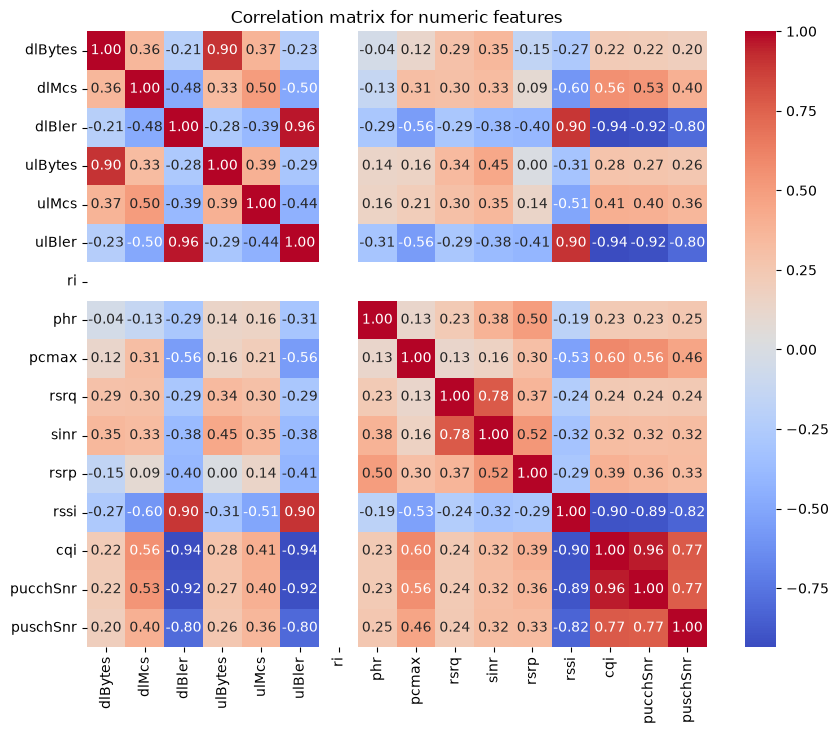

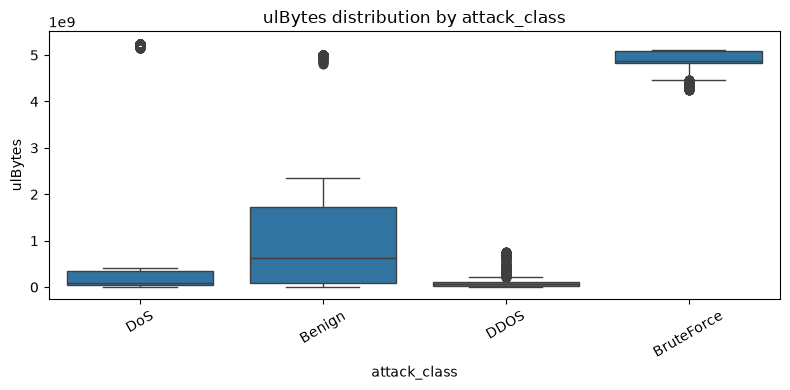

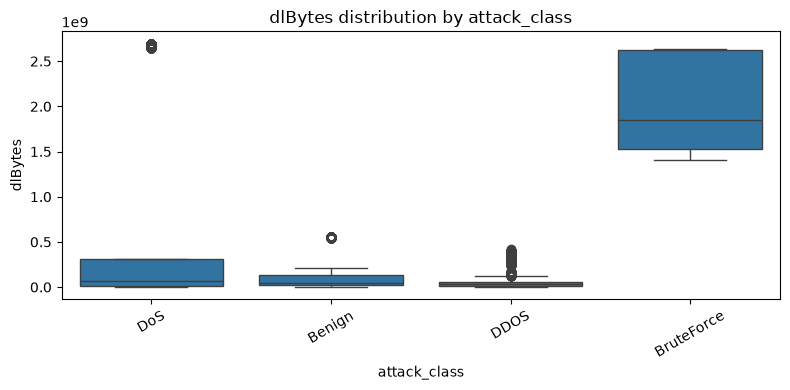

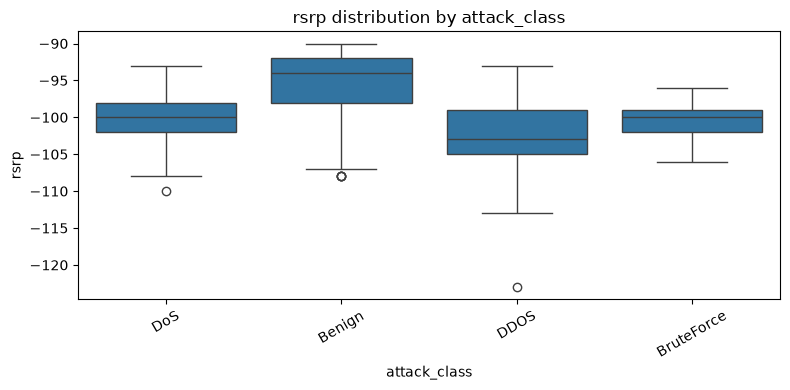

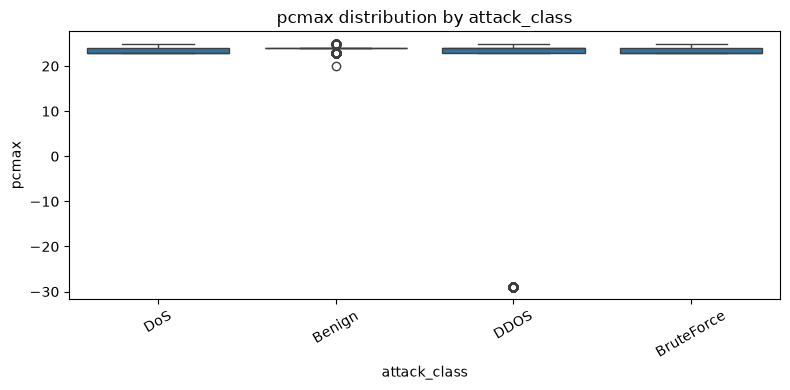

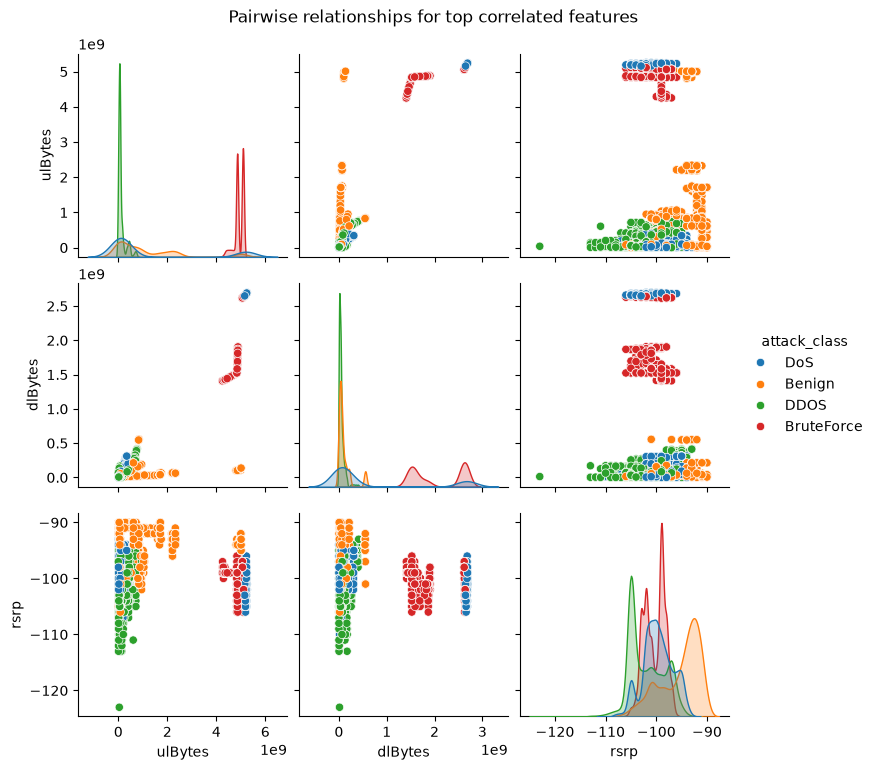

In [52]:
# Analyze balanced lower-layer dataset by attack class
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


print("Using balanced dataset for analysis")
print(df["attack_class"].value_counts())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns:", numeric_cols)

if not numeric_cols:
    print("No numeric features available for analysis.")
else:
    corr = df[numeric_cols].corr()

    codes, names = pd.factorize(df["attack_class"])
    attack_corr = {
        col: np.corrcoef(df[col].astype(float), codes)[0, 1]
        for col in numeric_cols
        if df[col].notna().any()
    }
    attack_corr_series = pd.Series(attack_corr).abs().sort_values(ascending=False)
    print("\nTop numeric features correlated with attack_class:")
    print(attack_corr_series.head(10))

    top_features = attack_corr_series.head(6).index.tolist()
    print("\nMean values by attack_class for top features:")
    display(df.groupby("attack_class")[top_features].mean())

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation matrix for numeric features")
    plt.show()

    for feature in top_features[:4]:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x="attack_class", y=feature, data=df)
        plt.title(f"{feature} distribution by attack_class")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

    if len(top_features) >= 3:
        sns.pairplot(df, vars=top_features[:3], hue="attack_class", height=2.5)
        plt.suptitle("Pairwise relationships for top correlated features", y=1.02)
        plt.show()

   

In [55]:
 # Outlier summary for top features using IQR
print("\nOutlier counts for top features:")
outlier_summary = {}
for feature in top_features[:6]:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[feature] < lower) | (df[feature] > upper)]
    outlier_summary[feature] = len(outliers)
    print(f"{feature}: {len(outliers):,} outliers ({len(outliers) / len(df):.1%})")


Outlier counts for top features:
ulBytes: 0 outliers (0.0%)
dlBytes: 0 outliers (0.0%)
rsrp: 25 outliers (0.2%)
pcmax: 519 outliers (4.2%)
rsrq: 155 outliers (1.3%)
dlMcs: 0 outliers (0.0%)


Summary: plots show relatively few outliers for these top features, consistent with the visuals.